# Seaborn - FAQ (Frequently Asked Questions)

Odpowiedzi na najczęściej zadawane pytania o Seaborn.

**Spis treści:**
1. Jak działa automatyczna agregacja w `lineplot()`?
2. [Kolejne pytania tutaj...]

---

## 1. 🤔 Jak działa automatyczna agregacja w `lineplot()`?

**Pytanie:** "Skąd seaborn wie, że ma uśredniać dane? Nie napisałem mu tego!"

### Kluczowa różnica między matplotlib a seaborn:

**Matplotlib `plot()`:**
- Łączy punkty w kolejności, jak są w danych
- Jeśli dla tego samego `x` są różne `y` → dostaniesz wiele punktów na tej samej pozycji X
- Musisz **ręcznie** obliczyć średnią jeśli chcesz

**Seaborn `lineplot()`:**
- **Automatycznie agreguje** dane dla każdej unikalnej wartości `x`
- Jeśli dla `x=1` masz wiele wartości `y` (np. 10, 15, 12) → seaborn:
  1. Oblicza **średnią** (domyślnie) → np. 12.33
  2. Oblicza **95% przedział ufności** (CI) wokół średniej
  3. Rysuje linię przez średnie + zacieniowany obszar (CI)
- Jeśli dla każdego `x` jest dokładnie jedno `y` → po prostu łączy punkty (bez agregacji)

### Przykład:

```python
# Dane: dla każdego miesiąca mamy WIELE pomiarów temperatury
# Styczeń: -2°C, -5°C, 0°C, -3°C, ... (31 dni)
# Luty: -1°C, 2°C, -4°C, ... (28 dni)

sns.lineplot(data=df_pogoda, x='miesiac', y='temperatura')

# Seaborn automatycznie:
# - Dla miesiąca=1: obliczy średnią z 31 pomiarów → np. -2.5°C
# - Dla miesiąca=2: obliczy średnią z 28 pomiarów → np. -1.2°C
# - Narysuje linię przez te średnie
# - Pokaże przedział ufności (jasny obszar)
```

### Co się dzieje krok po kroku:

In [4]:
import pandas as pd
import numpy as np

# Przykładowe dane
data = pd.DataFrame({
    'miesiac': [1,1,1,1,1,1, 2,2,2,2, 3],
    'temperatura': [10, 15, 12, 8, 14, 11, 20, 18, 22, 19, 25]
})

print("📊 Dane wejściowe:")
print(data)

print("\n💡 Co seaborn zrobi:")
print("\n1. Grupuje dane po 'miesiac':")
for miesiac in sorted(data['miesiac'].unique()):
    temp_values = data[data['miesiac'] == miesiac]['temperatura'].values
    print(f"   Miesiąc {miesiac}: {temp_values}")

print("\n2. Dla każdej grupy oblicza średnią:")
for miesiac in sorted(data['miesiac'].unique()):
    temp_values = data[data['miesiac'] == miesiac]['temperatura']
    mean = temp_values.mean()
    std = temp_values.std()
    print(f"   Miesiąc {miesiac}: średnia = {mean:.2f}°C, std = {std:.2f}°C")

print("\n3. Oblicza przedział ufności (CI 95%):")
print("   Używa odchylenia standardowego i rozmiar próby")
print("   CI ≈ mean ± 1.96 * (std / sqrt(n))")

print("\n4. Rysuje wykres:")
print("   - Punkt w (x, mean)")
print("   - Zacieniowany obszar dla CI")
print("   - Łączy punkty linią")

📊 Dane wejściowe:
    miesiac  temperatura
0         1           10
1         1           15
2         1           12
3         1            8
4         1           14
5         1           11
6         2           20
7         2           18
8         2           22
9         2           19
10        3           25

💡 Co seaborn zrobi:

1. Grupuje dane po 'miesiac':
   Miesiąc 1: [10 15 12  8 14 11]
   Miesiąc 2: [20 18 22 19]
   Miesiąc 3: [25]

2. Dla każdej grupy oblicza średnią:
   Miesiąc 1: średnia = 11.67°C, std = 2.58°C
   Miesiąc 2: średnia = 19.75°C, std = 1.71°C
   Miesiąc 3: średnia = 25.00°C, std = nan°C

3. Oblicza przedział ufności (CI 95%):
   Używa odchylenia standardowego i rozmiar próby
   CI ≈ mean ± 1.96 * (std / sqrt(n))

4. Rysuje wykres:
   - Punkt w (x, mean)
   - Zacieniowany obszar dla CI
   - Łączy punkty linią


### Wizualizacja - przykład z danymi

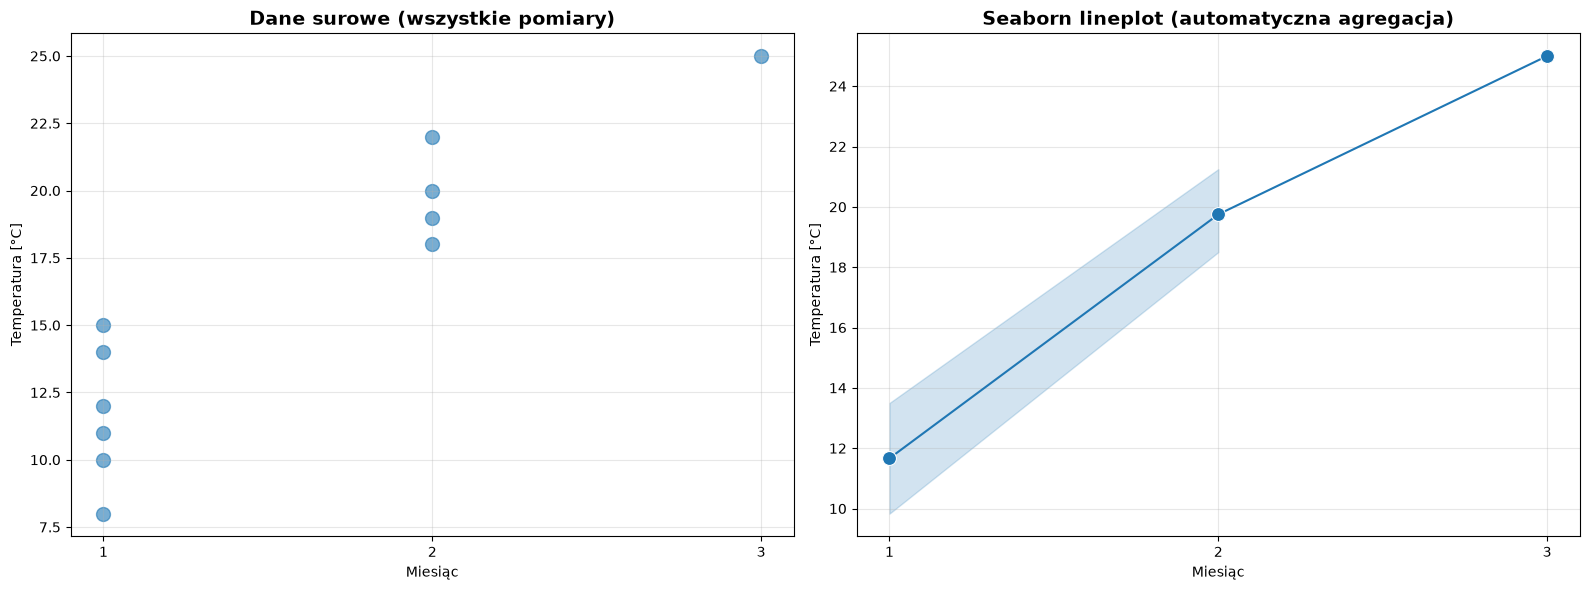


📊 RÓŻNICA:
   LEWY: Wszystkie 11 punktów widoczne
   PRAWY: 3 punkty (średnie) + zacieniowany obszar (CI)


In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Te same przykładowe dane
data = pd.DataFrame({
    'miesiac': [1,1,1,1,1,1, 2,2,2,2, 3],
    'temperatura': [10, 15, 12, 8, 14, 11, 20, 18, 22, 19, 25]
})

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Wykres 1: Wszystkie punkty (matplotlib)
axes[0].scatter(data['miesiac'], data['temperatura'], s=100, alpha=0.6)
axes[0].set_title('Dane surowe (wszystkie pomiary)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Miesiąc')
axes[0].set_ylabel('Temperatura [°C]')
axes[0].grid(True, alpha=0.3)
axes[0].set_xticks([1, 2, 3])

# Wykres 2: Seaborn lineplot (automatyczna agregacja)
sns.lineplot(data=data, x='miesiac', y='temperatura', ax=axes[1], marker='o', markersize=10)
axes[1].set_title('Seaborn lineplot (automatyczna agregacja)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Miesiąc')
axes[1].set_ylabel('Temperatura [°C]')
axes[1].grid(True, alpha=0.3)
axes[1].set_xticks([1, 2, 3])

plt.tight_layout()
plt.show()

print("\n📊 RÓŻNICA:")
print("   LEWY: Wszystkie 11 punktów widoczne")
print("   PRAWY: 3 punkty (średnie) + zacieniowany obszar (CI)")

### Jak seaborn podejmuje decyzję?

**Pseudokod algorytmu:**

```python
for each unique_x in x_values:
    y_values_for_this_x = get_all_y_where_x_equals(unique_x)

    if len(y_values_for_this_x) > 1:
        # Wiele wartości y dla tego x → agreguj
        mean = calculate_mean(y_values_for_this_x)
        ci = calculate_confidence_interval(y_values_for_this_x)
        plot_point_with_ci(unique_x, mean, ci)
    else:
        # Tylko jedna wartość y dla tego x → bez agregacji
        plot_point(unique_x, y_values_for_this_x[0])

# Połącz wszystkie punkty linią
```

✅ **Seaborn agreguje automatycznie** gdy dla tego samego `x` jest wiele `y`  
✅ **Jeśli każdy x ma jedno y** → po prostu łączy punkty (bez agregacji)

---

### Parametry kontrolujące agregację

**Funkcja agregująca (`estimator`):**

```python
sns.lineplot(x='x', y='y', estimator='mean')     # Domyślnie - średnia
sns.lineplot(x='x', y='y', estimator='median')   # Mediana
sns.lineplot(x='x', y='y', estimator='sum')      # Suma
sns.lineplot(x='x', y='y', estimator=np.min)     # Minimum (dowolna funkcja)
```

**Przedział błędu (`errorbar`):**

```python
sns.lineplot(x='x', y='y', errorbar=('ci', 95))  # Domyślnie - 95% CI
sns.lineplot(x='x', y='y', errorbar='sd')        # Odchylenie standardowe
sns.lineplot(x='x', y='y', errorbar='se')        # Błąd standardowy
sns.lineplot(x='x', y='y', errorbar=None)        # Brak przedziału (tylko linia)
```

**Uwaga:** W starszych wersjach seaborn (< 0.12) używaj `ci=None` zamiast `errorbar=None`.

### Przykłady z różnymi ustawieniami

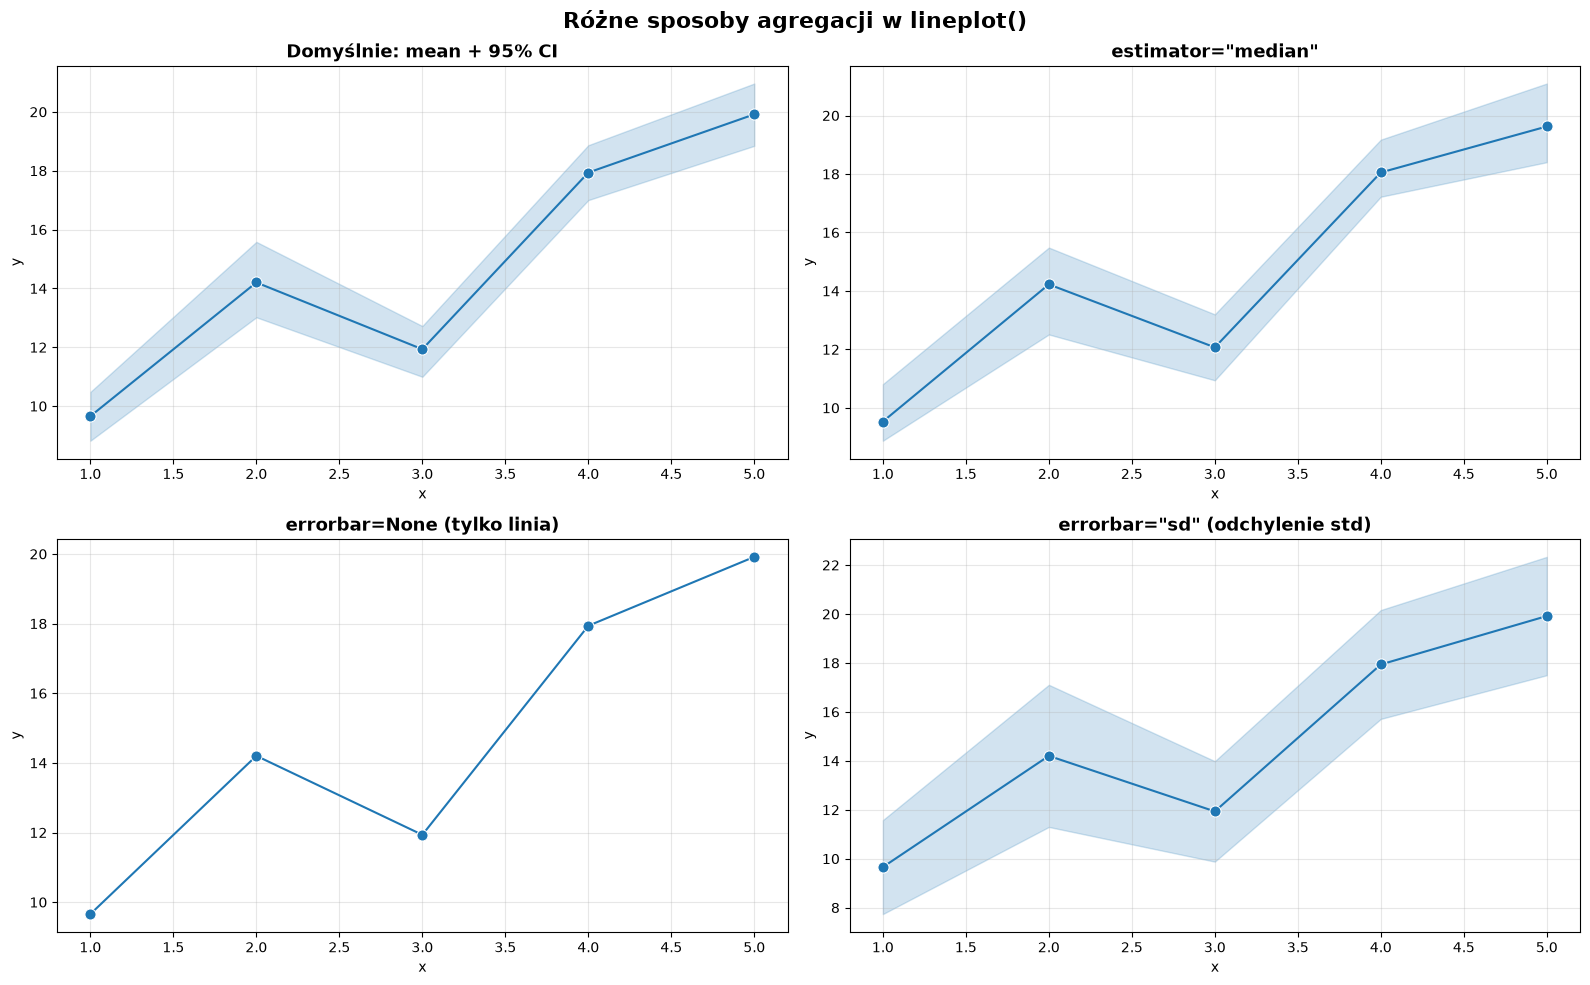

📊 Opcje agregacji (estimator):
   'mean' - średnia (domyślnie)
   'median' - mediana
   'sum' - suma
   np.min, np.max - dowolna funkcja numpy

📊 Opcje errorbar:
   ('ci', 95) - 95% przedział ufności (domyślnie)
   'sd' - odchylenie standardowe
   'se' - błąd standardowy
   None - brak przedziału


In [6]:
# Dane z wieloma pomiarami dla tego samego x
np.random.seed(42)
data_multi = pd.DataFrame({
    'x': np.repeat([1, 2, 3, 4, 5], 20),
    'y': np.concatenate([
        np.random.normal(10, 2, 20),
        np.random.normal(15, 3, 20),
        np.random.normal(12, 2.5, 20),
        np.random.normal(18, 2, 20),
        np.random.normal(20, 3.5, 20)
    ])
})

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Domyślnie - średnia + 95% CI
sns.lineplot(data=data_multi, x='x', y='y', ax=axes[0, 0], marker='o', markersize=8)
axes[0, 0].set_title('Domyślnie: mean + 95% CI', fontsize=13, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)

# 2. Mediana zamiast średniej
sns.lineplot(data=data_multi, x='x', y='y', estimator='median', ax=axes[0, 1], marker='o', markersize=8)
axes[0, 1].set_title('estimator="median"', fontsize=13, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)

# 3. Bez przedziału ufności
sns.lineplot(data=data_multi, x='x', y='y', errorbar=None, ax=axes[1, 0], marker='o', markersize=8)
axes[1, 0].set_title('errorbar=None (tylko linia)', fontsize=13, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)

# 4. Odchylenie standardowe
sns.lineplot(data=data_multi, x='x', y='y', errorbar='sd', ax=axes[1, 1], marker='o', markersize=8)
axes[1, 1].set_title('errorbar="sd" (odchylenie std)', fontsize=13, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)

plt.suptitle('Różne sposoby agregacji w lineplot()', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print("📊 Opcje agregacji (estimator):")
print("   'mean' - średnia (domyślnie)")
print("   'median' - mediana")
print("   'sum' - suma")
print("   np.min, np.max - dowolna funkcja numpy")
print("\n📊 Opcje errorbar:")
print("   ('ci', 95) - 95% przedział ufności (domyślnie)")
print("   'sd' - odchylenie standardowe")
print("   'se' - błąd standardowy")
print("   None - brak przedziału")

---

### Podsumowanie

✅ **Seaborn agreguje automatycznie** gdy dla tego samego `x` jest wiele `y`  
✅ **Domyślnie używa średniej** + 95% przedział ufności  
✅ **Jeśli każdy x ma jedno y** → po prostu łączy punkty (bez agregacji)  
✅ **Możesz kontrolować** metodę agregacji (`estimator`) i przedział błędu (`errorbar`)  

💡 **Jeśli nie chcesz agregacji** - użyj `errorbar=None` lub przejdź na matplotlib `plt.plot()`.